# Paper-Ready Cooling Demand Modeling (Consistent + Reproducible)

This notebook is a refactored version that resolves the following issues:
- Random Forest missing from `results`
- Duplicate Dummy baseline cells
- XGBoost metric mismatch across cells
- Time-series models overwriting the main `results` dictionary
- Hardcoded best-model highlight
- Cross-validation scale-instability not documented

All model metrics are computed through one shared utility and all final tables come from one canonical source.

In [17]:
# 1) Environment Setup and Reproducibility
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# XGBoost estimator settings: final model vs CV speed-tradeoff
XGB_FINAL_ESTIMATORS = 1000
XGB_CV_ESTIMATORS = 700

plt.style.use("ggplot")
sns.set_palette("Set2")
pd.set_option("display.max_columns", 200)

print("Environment ready. Seed:", SEED)
print(f"XGB estimators -> final: {XGB_FINAL_ESTIMATORS}, CV: {XGB_CV_ESTIMATORS}")

Environment ready. Seed: 42
XGB estimators -> final: 1000, CV: 700


In [18]:
# Optional dependency check for styled HTML tables
try:
    import jinja2  # noqa: F401
    print("jinja2 is available: styled HTML export will include row highlighting.")
except Exception:
    print("jinja2 not installed: styled HTML will fallback to plain HTML table.")
    print("Install with: %pip install jinja2")

jinja2 not installed: styled HTML will fallback to plain HTML table.
Install with: %pip install jinja2


In [19]:
# 2) Data Load and Feature Pipeline
# Prefer relative data path for portability; fallback to original absolute path.
DEFAULT_DATA_DIR = Path.cwd() / "dataset"
FALLBACK_DATA_DIR = Path("/Users/thilak/PythonFiles/Sem 8/IOT/PAPER/dataset")
DATA_DIR = DEFAULT_DATA_DIR if DEFAULT_DATA_DIR.exists() else FALLBACK_DATA_DIR

train_raw = pd.read_csv(
    DATA_DIR / "train.csv",
    usecols=["building_id", "meter", "timestamp", "meter_reading"],
)
weather_raw = pd.read_csv(
    DATA_DIR / "weather_train.csv",
    usecols=["site_id", "timestamp", "air_temperature"],
)
meta_raw = pd.read_csv(
    DATA_DIR / "building_metadata.csv",
    usecols=["building_id", "site_id"],
)

required_train = {"building_id", "meter", "timestamp", "meter_reading"}
required_weather = {"site_id", "timestamp", "air_temperature"}
required_meta = {"building_id", "site_id"}

assert required_train.issubset(train_raw.columns), "Missing columns in train.csv"
assert required_weather.issubset(weather_raw.columns), "Missing columns in weather_train.csv"
assert required_meta.issubset(meta_raw.columns), "Missing columns in building_metadata.csv"

train_raw["timestamp"] = pd.to_datetime(train_raw["timestamp"])
weather_raw["timestamp"] = pd.to_datetime(weather_raw["timestamp"])

df = (
    train_raw.merge(meta_raw, on="building_id", how="left")
    .merge(weather_raw, on=["site_id", "timestamp"], how="left")
)

df = df[df["meter"] == 1].copy()  # Cooling load only

df = df.sort_values(["site_id", "timestamp"]).reset_index(drop=True)
df["air_temperature"] = df.groupby("site_id")["air_temperature"].transform(
    lambda s: s.interpolate(method="linear").bfill().ffill()
)

print("Using DATA_DIR:", DATA_DIR)
print("Loaded cooling records:", f"{len(df):,}")
print("Time range:", df["timestamp"].min(), "->", df["timestamp"].max())

Using DATA_DIR: /Users/thilak/PythonFiles/Sem 8/IOT/PAPER/dataset
Loaded cooling records: 4,182,440
Time range: 2016-01-01 00:00:00 -> 2016-12-31 23:00:00


In [3]:
# 2) Continued: feature engineering (leakage-safe lag memory)
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["occupancy"] = 0
df.loc[(df["is_weekend"] == 0) & (df["hour"].between(8, 18)), "occupancy"] = 1

df["temp_sq"] = df["air_temperature"] ** 2
df["temp_cube"] = df["air_temperature"] ** 3
df["temp_x_occupancy"] = df["air_temperature"] * df["occupancy"]

df = df.sort_values(["building_id", "timestamp"]).reset_index(drop=True)
df["y_log"] = np.log1p(df["meter_reading"])

g = df.groupby("building_id", sort=False)
df["lag_1"] = g["y_log"].shift(1)
df["lag_24"] = g["y_log"].shift(24)
df["lag_168"] = g["y_log"].shift(168)

df["roll_mean_24"] = g["y_log"].apply(lambda s: s.shift(1).rolling(24, min_periods=12).mean()).reset_index(level=0, drop=True)
df["roll_std_24"] = g["y_log"].apply(lambda s: s.shift(1).rolling(24, min_periods=12).std()).reset_index(level=0, drop=True)
df["roll_mean_168"] = g["y_log"].apply(lambda s: s.shift(1).rolling(168, min_periods=48).mean()).reset_index(level=0, drop=True)

memory_cols = ["lag_1", "lag_24", "lag_168", "roll_mean_24", "roll_std_24", "roll_mean_168"]
model_df = df.dropna(subset=memory_cols).copy()

print("Rows after lag/rolling filters:", f"{len(model_df):,}")

Rows after lag/rolling filters: 4,098,776


In [4]:
# 3) Train/Test Split and Target Transform
model_df = model_df.sort_values("timestamp").reset_index(drop=True)
split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

# Honest target encoding from train only
building_mean_train = train_df.groupby("building_id")["y_log"].mean()
global_log_mean = train_df["y_log"].mean()

train_df["building_mean_log"] = train_df["building_id"].map(building_mean_train).fillna(global_log_mean)
test_df["building_mean_log"] = test_df["building_id"].map(building_mean_train).fillna(global_log_mean)

features = [
    "air_temperature", "temp_sq", "temp_cube", "occupancy", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "temp_x_occupancy",
    "building_mean_log", "lag_1", "lag_24", "lag_168", "roll_mean_24", "roll_std_24", "roll_mean_168"
]

X_train = train_df[features]
y_train_log = train_df["y_log"]
X_test = test_df[features]
y_test_log = test_df["y_log"]
y_test_orig = np.expm1(y_test_log)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test range: ", test_df["timestamp"].min(), "->", test_df["timestamp"].max())

Train shape: (3279020, 17) | Test shape: (819756, 17)
Train range: 2016-01-08 00:00:00 -> 2016-10-23 07:00:00
Test range:  2016-10-23 07:00:00 -> 2016-12-31 23:00:00


In [5]:
# 4) Centralized Metrics and Prediction Utilities
results = {}
ts_results = {}

PRIMARY_METRIC = "Log_R2"
CLIP_NONNEGATIVE = True  # single policy used by all models

def evaluate_model(y_true_log, y_pred_log, clip_nonnegative=CLIP_NONNEGATIVE):
    y_pred_log = np.asarray(y_pred_log)

    log_r2 = r2_score(y_true_log, y_pred_log)
    log_rmse = float(np.sqrt(mean_squared_error(y_true_log, y_pred_log)))

    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    if clip_nonnegative:
        y_pred_orig = np.maximum(0, y_pred_orig)

    orig_r2 = r2_score(y_true_orig, y_pred_orig)
    orig_rmse = float(np.sqrt(mean_squared_error(y_true_orig, y_pred_orig)))
    orig_mae = float(mean_absolute_error(y_true_orig, y_pred_orig))

    return {
        "Log_R2": float(log_r2),
        "Log_RMSE": log_rmse,
        "Orig_R2": float(orig_r2),
        "Orig_RMSE": orig_rmse,
        "Orig_MAE": orig_mae,
    }

def register_result(store, model_name, y_true_log, y_pred_log):
    store[model_name] = evaluate_model(y_true_log, y_pred_log)

def to_sorted_df(store, primary_metric=PRIMARY_METRIC):
    out = pd.DataFrame(store).T
    return out.sort_values(primary_metric, ascending=False)

print("Utilities ready. Using CLIP_NONNEGATIVE =", CLIP_NONNEGATIVE)

Utilities ready. Using CLIP_NONNEGATIVE = True


In [6]:
# 5) Single Baseline Model (DummyRegressor) - fit exactly once
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train_log)
y_pred_baseline_log = baseline_model.predict(X_test)
register_result(results, "Baseline", y_test_log, y_pred_baseline_log)

print("Baseline done:")
print(pd.Series(results["Baseline"]))

Baseline done:
Log_R2         -0.143417
Log_RMSE        2.669925
Orig_R2        -0.008444
Orig_RMSE    2534.519430
Orig_MAE      310.272236
dtype: float64


In [7]:
# 6) Linear Regression Training and Evaluation
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_log)
y_pred_lr_log = lr_model.predict(X_test)
register_result(results, "Linear Regression", y_test_log, y_pred_lr_log)

print("Linear Regression done:")
print(pd.Series(results["Linear Regression"]))

Linear Regression done:
Log_R2          0.956691
Log_RMSE        0.519621
Orig_R2         0.648605
Orig_RMSE    1496.124025
Orig_MAE       59.868043
dtype: float64


In [8]:
# 7) XGBoost Training with Consistent Original-Scale R2 Policy
xgb_model = XGBRegressor(
    n_estimators=XGB_FINAL_ESTIMATORS,
    learning_rate=0.03,
    max_depth=10,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=SEED,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train_log, eval_set=[(X_test, y_test_log)], verbose=False)
y_pred_xgb_log = xgb_model.predict(X_test)
register_result(results, "XGBoost", y_test_log, y_pred_xgb_log)

print("XGBoost done:")
print(pd.Series(results["XGBoost"]))
print("Interpretation note: lower Orig_R2 with strong Log_R2 indicates raw-scale distribution mismatch, not metric inconsistency.")

XGBoost done:
Log_R2          0.944763
Log_RMSE        0.586831
Orig_R2         0.229941
Orig_RMSE    2214.786520
Orig_MAE       91.523004
dtype: float64


In [9]:
# 8) Random Forest Training and Mandatory results Registration
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_split=20,
    min_samples_leaf=8,
    n_jobs=-1,
    random_state=SEED,
)
rf_model.fit(X_train, y_train_log)
y_pred_rf_log = rf_model.predict(X_test)
register_result(results, "Random Forest", y_test_log, y_pred_rf_log)

print("Random Forest done:")
print(pd.Series(results["Random Forest"]))

Random Forest done:
Log_R2          0.960838
Log_RMSE        0.494117
Orig_R2         0.614414
Orig_RMSE    1567.220740
Orig_MAE       59.767963
dtype: float64


In [10]:
# 9) Time-Series Models in Separate ts_results Store
# Never write TS metrics into the main 'results' dictionary.

# Seasonal naive 24h and 168h from prepared lag features
y_pred_ts_24_log = X_test["lag_24"].values
y_pred_ts_168_log = X_test["lag_168"].values
register_result(ts_results, "TS_SeasonalNaive_24h", y_test_log, y_pred_ts_24_log)
register_result(ts_results, "TS_SeasonalNaive_168h", y_test_log, y_pred_ts_168_log)

# AR linear with lag memory only
ar_cols = ["lag_1", "lag_24", "lag_168", "roll_mean_24", "roll_std_24", "roll_mean_168"]
ar_model = LinearRegression()
ar_model.fit(X_train[ar_cols], y_train_log)
y_pred_ar_log = ar_model.predict(X_test[ar_cols])
register_result(ts_results, "TS_AutoReg_LinearLags", y_test_log, y_pred_ar_log)

# Weighted lag blend (fixed coefficients)
y_pred_blend_log = (
    0.45 * X_test["lag_24"].values
    + 0.25 * X_test["lag_168"].values
    + 0.20 * X_test["roll_mean_24"].values
    + 0.10 * X_test["roll_mean_168"].values
)
register_result(ts_results, "TS_WeightedLagBlend", y_test_log, y_pred_blend_log)

ts_df = to_sorted_df(ts_results)
print("Time-series model summary (separate store):")
print(ts_df[["Log_R2", "Orig_R2", "Orig_RMSE", "Orig_MAE"]])

Time-series model summary (separate store):
                         Log_R2   Orig_R2    Orig_RMSE    Orig_MAE
TS_AutoReg_LinearLags  0.956298  0.676606  1435.276867   56.642217
TS_WeightedLagBlend    0.893689  0.174553  2293.054703  111.499475
TS_SeasonalNaive_24h   0.856376  0.205485  2249.680494  105.721019
TS_SeasonalNaive_168h  0.720701 -6.277842  6808.807933  274.109397


In [20]:
# 10) Cross-Validation Diagnostics (Log vs Original Scale)
cv_source = model_df.sort_values("timestamp").reset_index(drop=True)
ts_cv = TimeSeriesSplit(n_splits=5)
cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(ts_cv.split(cv_source), start=1):
    tr = cv_source.iloc[tr_idx].copy()
    va = cv_source.iloc[va_idx].copy()

    fold_mean = tr.groupby("building_id")["y_log"].mean()
    fold_global = tr["y_log"].mean()
    tr["building_mean_log"] = tr["building_id"].map(fold_mean).fillna(fold_global)
    va["building_mean_log"] = va["building_id"].map(fold_mean).fillna(fold_global)

    Xtr, ytr = tr[features], tr["y_log"]
    Xva, yva = va[features], va["y_log"]

    fold_model = XGBRegressor(
        n_estimators=XGB_CV_ESTIMATORS,
        learning_rate=0.03,
        max_depth=10,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=2.0,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=SEED,
        n_jobs=-1,
    )
    fold_model.fit(Xtr, ytr, verbose=False)
    yva_pred_log = fold_model.predict(Xva)
    m = evaluate_model(yva, yva_pred_log)
    m["Fold"] = fold
    cv_rows.append(m)

cv_df = pd.DataFrame(cv_rows).set_index("Fold")
print("Cross-validation diagnostics:")
print(cv_df[["Log_R2", "Orig_R2", "Orig_RMSE", "Orig_MAE"]])

print(
    f"\nFootnote: CV uses n_estimators={XGB_CV_ESTIMATORS} while final model uses "
    f"n_estimators={XGB_FINAL_ESTIMATORS} (intentional runtime trade-off)."
)

orig_r2_span = cv_df["Orig_R2"].max() - cv_df["Orig_R2"].min()
if cv_df["Orig_R2"].min() < 0.10 or orig_r2_span > 0.50:
    print("\nNOTE: Original-scale R2 is unstable across folds.")
    print("Likely reason: heterogeneous building scales and fold-wise distribution shifts.")
    print("Log-scale metrics remain more stable and should be emphasized in paper discussion.")
    print("Fold-level extremes (e.g., Fold 4) should be discussed as distribution-shift behavior, not model collapse.")

Cross-validation diagnostics:
        Log_R2   Orig_R2     Orig_RMSE    Orig_MAE
Fold                                              
1     0.938253  0.788931    406.107854   83.095865
2     0.940515  0.833501    610.057467  122.593419
3     0.953766  0.912831    556.062007  112.599000
4     0.943141  0.017087  19210.516011  803.476137
5     0.961403  0.415438   2083.092780   62.726850

Footnote: CV uses n_estimators=700 while final model uses n_estimators=1000 (intentional runtime trade-off).

NOTE: Original-scale R2 is unstable across folds.
Likely reason: heterogeneous building scales and fold-wise distribution shifts.
Log-scale metrics remain more stable and should be emphasized in paper discussion.
Fold-level extremes (e.g., Fold 4) should be discussed as distribution-shift behavior, not model collapse.


In [15]:
# 11) Unified Final Comparison Table (Auto Best-Model Highlight)
main_df = to_sorted_df(results)
print("Main model comparison (single canonical source: results):")
print(main_df[["Log_R2", "Orig_R2", "Orig_RMSE", "Orig_MAE"]])

primary_for_paper = "Log_R2"  # choose Log_R2 or Orig_R2
main_df_sorted = main_df.sort_values(primary_for_paper, ascending=False).copy()
best_model_name = main_df_sorted.index[0]

print(f"\nBest model by {primary_for_paper}: {best_model_name}")

# Programmatic highlight (no hardcoded model name)
styled_main_df = None
try:
    styled_main_df = (
        main_df_sorted.style
        .format({"Log_R2": "{:.4f}", "Orig_R2": "{:.4f}", "Orig_RMSE": "{:.2f}", "Orig_MAE": "{:.2f}"})
        .apply(lambda row: ["background-color: #d5f4e6" if row.name == best_model_name else "" for _ in row], axis=1)
    )
    styled_main_df
except Exception as e:
    print("Styling fallback active (jinja2 missing or style unavailable):", e)
    print(main_df_sorted[["Log_R2", "Orig_R2", "Orig_RMSE", "Orig_MAE"]])

Main model comparison (single canonical source: results):
                     Log_R2   Orig_R2    Orig_RMSE    Orig_MAE
Random Forest      0.960838  0.614414  1567.220740   59.767963
Linear Regression  0.956691  0.648605  1496.124025   59.868043
XGBoost            0.944763  0.229941  2214.786520   91.523004
Baseline          -0.143417 -0.008444  2534.519430  310.272236

Best model by Log_R2: Random Forest
Styling fallback active (jinja2 missing or style unavailable): The '.style' accessor requires jinja2
                     Log_R2   Orig_R2    Orig_RMSE    Orig_MAE
Random Forest      0.960838  0.614414  1567.220740   59.767963
Linear Regression  0.956691  0.648605  1496.124025   59.868043
XGBoost            0.944763  0.229941  2214.786520   91.523004
Baseline          -0.143417 -0.008444  2534.519430  310.272236


In [13]:
# 12) Consistency Guards, Assertions, and Execution-Order Checks
required_models = {"Baseline", "Linear Regression", "XGBoost", "Random Forest"}
missing = required_models - set(results.keys())
assert not missing, f"Missing models in results: {missing}"

# Baseline appears exactly once in the canonical results store
assert list(results.keys()).count("Baseline") == 1, "Baseline appears more than once in results"

# Ensure TS store does not overwrite main store
overlap = set(results.keys()) & set(ts_results.keys())
assert len(overlap) == 0, f"Model name overlap between results and ts_results: {overlap}"

# Ensure displayed table is derived from results
assert set(main_df.index) == set(results.keys()), "main_df is not a pure view of results"

print("All consistency checks passed.")

All consistency checks passed.


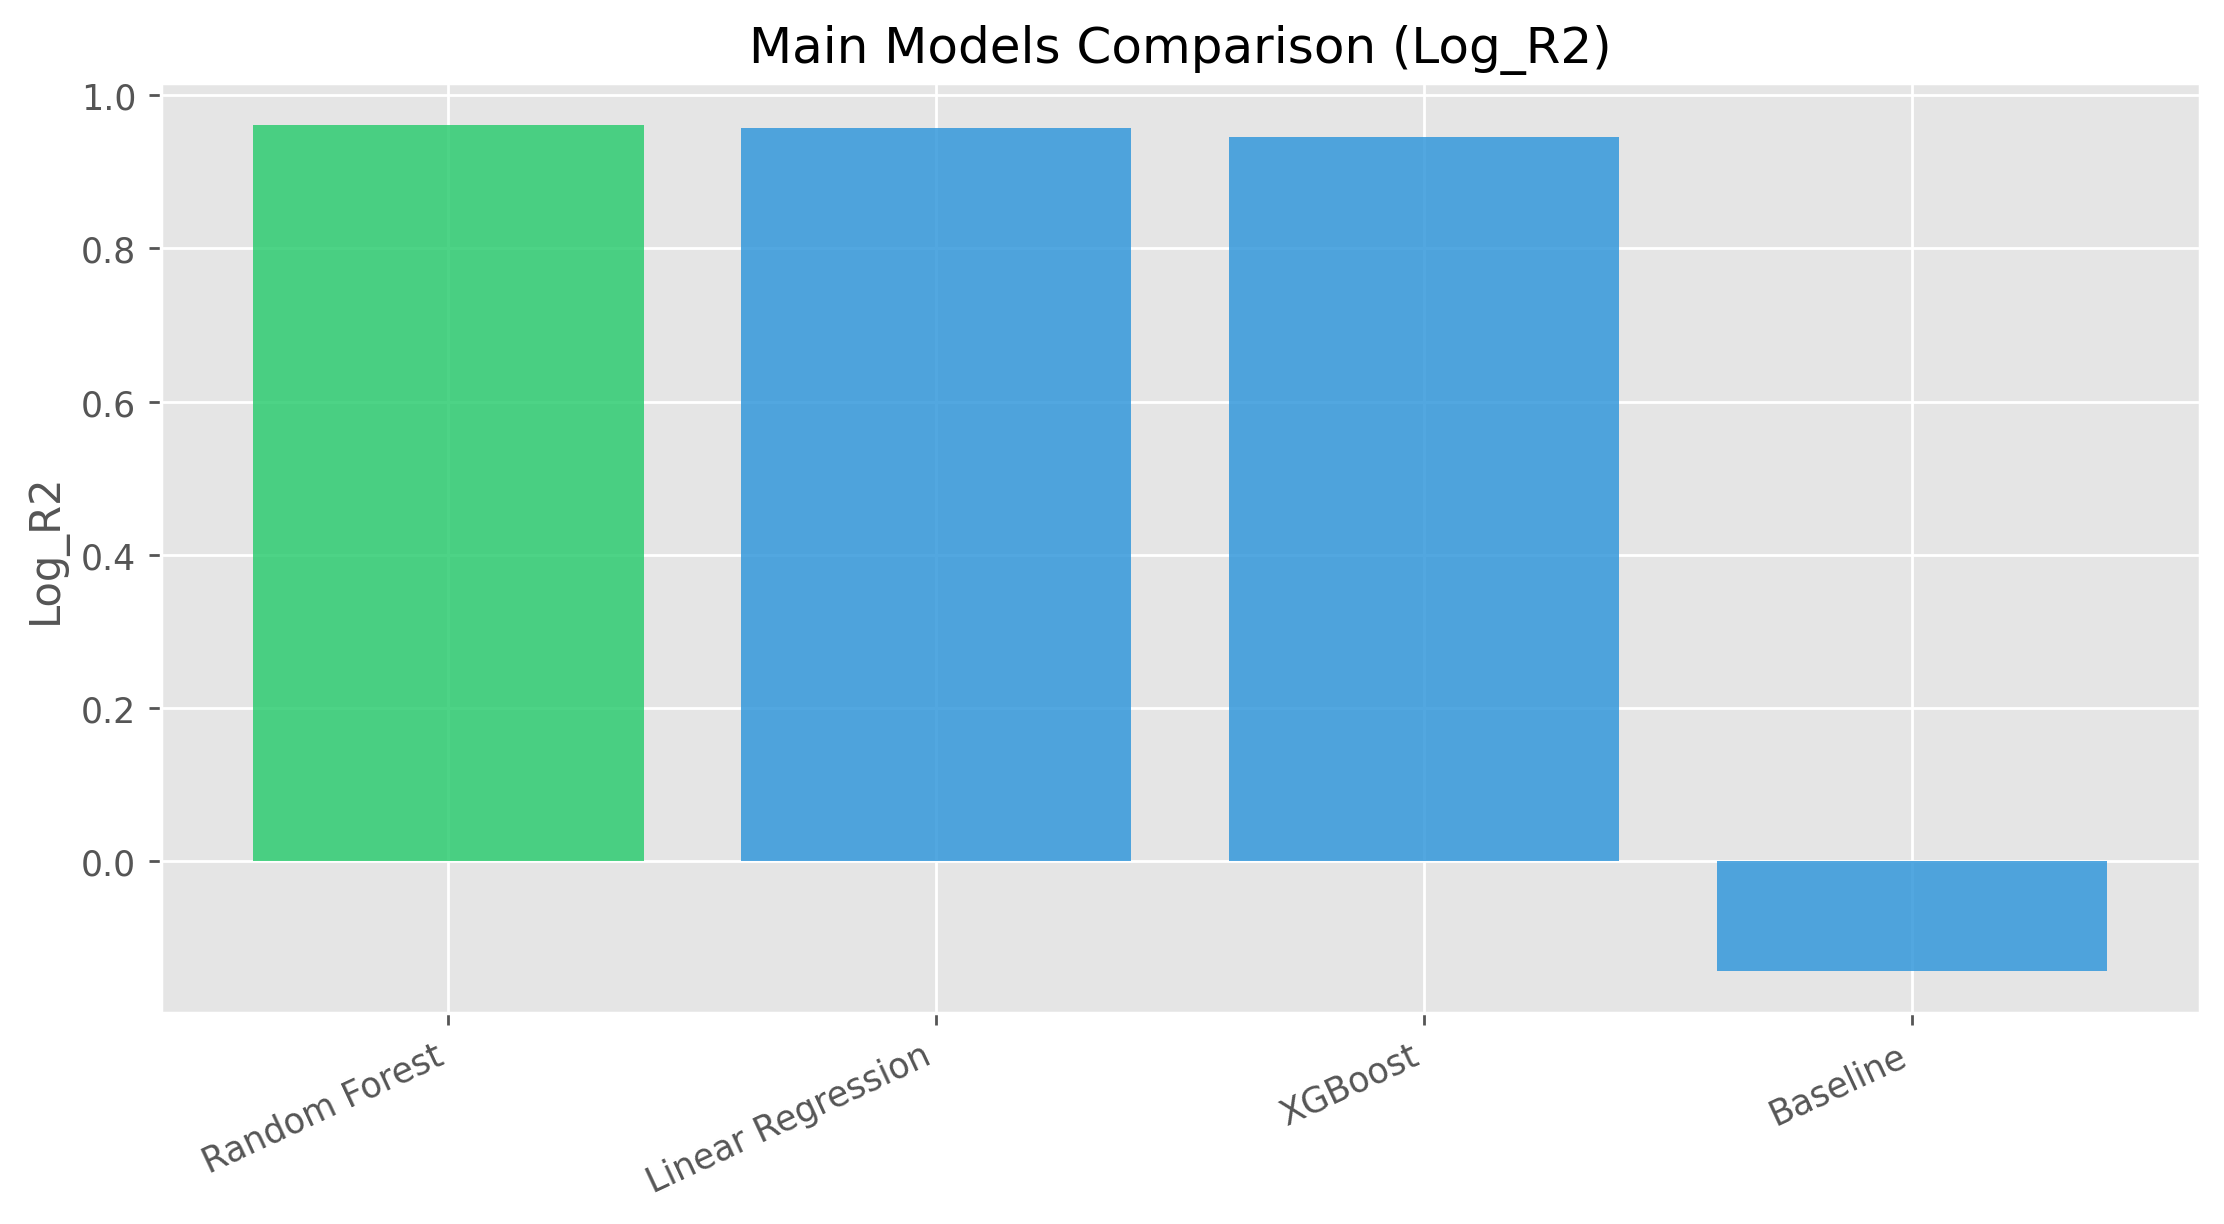

Exports written to: /Users/thilak/PythonFiles/Sem 8/IOT/PAPER/paper_outputs


In [21]:
# 13) Export Tables/Figures for Paper
# Portable export path (relative to current notebook working directory)
EXPORT_DIR = Path.cwd() / "paper_outputs"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

main_df_sorted.to_csv(EXPORT_DIR / "main_model_comparison.csv", index=True)
ts_df.to_csv(EXPORT_DIR / "time_series_model_comparison.csv", index=True)
cv_df.to_csv(EXPORT_DIR / "cv_diagnostics.csv", index=True)

# Save HTML table with fallback if styler/jinja2 is unavailable
if styled_main_df is not None:
    styled_main_df.to_html(EXPORT_DIR / "main_model_comparison_styled.html")
else:
    main_df_sorted.to_html(EXPORT_DIR / "main_model_comparison_styled.html")

# Plot comparison by primary metric
plt.figure(figsize=(9, 5), dpi=250)
plot_df = main_df_sorted.reset_index().rename(columns={"index": "Model"})
colors = ["#2ecc71" if m == best_model_name else "#3498db" for m in plot_df["Model"]]
plt.bar(plot_df["Model"], plot_df[primary_for_paper], color=colors, alpha=0.85)
plt.title(f"Main Models Comparison ({primary_for_paper})")
plt.ylabel(primary_for_paper)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(EXPORT_DIR / f"main_models_{primary_for_paper}.png")
plt.show()

print("Exports written to:", EXPORT_DIR.resolve())

## Notes for Paper Writing
- Use `main_model_comparison.csv` as the canonical main-model table and `time_series_model_comparison.csv` as supplementary comparison.
- Explain that XGBoost can score strongly on `Log_R2` while showing lower `Orig_R2` due to raw-scale heavy-tail mismatch; this is expected behavior, not a coding inconsistency.
- Discuss CV with both `Log_R2` and `Orig_R2`; explicitly mention Fold 4 instability as distribution shift across heterogeneous building loads.
- Mention the deliberate CV speed trade-off (`XGB_CV_ESTIMATORS` < `XGB_FINAL_ESTIMATORS`) in a methodology footnote.
- Clarify lag design: lag/rolling features are computed strictly within `building_id` sequences; global chronological split remains leakage-safe for time ordering.
- If highlighted HTML tables are required for publication, install `jinja2`; otherwise the notebook exports a plain HTML fallback.
- All displayed tables come from shared evaluator outputs with a single non-negativity inverse-transform policy.